In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Removed: import seaborn as sns 
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, \
                            precision_score, recall_score, f1_score, \
                            classification_report
import tensorflow as tf
import os # Needed for saving plots in callback

# Assume your val_dataset is already defined and batched
# Example: val_dataset = tf.keras.preprocessing.image_dataset_from_directory(...)

# ---------------------------------------------------------------------------
# 1. Standalone Function for Post-Training Analysis (Matplotlib)
# ---------------------------------------------------------------------------

def analyze_model_outputs(model: tf.keras.Model, 
                          val_dataset: tf.data.Dataset, 
                          dataset_name: str = "Validation",
                          METRIC_THRESHOLD: float = 0.5):
    """
    Analyzes model predictions on a given dataset using Matplotlib for histograms.

    Args:
        model: The trained Keras model.
        val_dataset: The tf.data.Dataset to evaluate on.
        dataset_name: Name for plot titles (e.g., "Validation", "Test").
    """
    print(f"\n--- Analyzing Model Outputs on {dataset_name} Set ---")

    # --- Get Predictions and True Labels ---
    print("Gathering predictions and true labels...")
    try:
        predictions_raw = model.predict(val_dataset)
        true_labels = []
        for _, y_batch in val_dataset:
            true_labels.append(y_batch.numpy())
        true_labels = np.concatenate(true_labels, axis=0).flatten()
        predictions_proba = predictions_raw.flatten()

        if len(predictions_proba) != len(true_labels):
             print(f"Warning: Number of predictions ({len(predictions_proba)}) "
                   f"does not match number of labels ({len(true_labels)}). "
                   f"Check dataset configuration.")
             # Attempt to reconcile if predictions has an extra dim (unlikely here)
             if predictions_proba.shape[0] != true_labels.shape[0] and len(predictions_proba.shape) > 1:
                 print("Attempting to flatten predictions further.")
                 predictions_proba = predictions_proba.reshape(-1) # Or adjust based on actual shape
                 if len(predictions_proba) != len(true_labels):
                     raise ValueError("Cannot reconcile prediction and label shapes.")

    except Exception as e:
        print(f"Error during prediction or label extraction: {e}")
        print("Check dataset structure and model output shape.")
        return

    print(f"Successfully gathered {len(true_labels)} labels and predictions.")

    # --- Plot Histogram of Predicted Probabilities (Matplotlib) ---
    print("Plotting histogram of predicted probabilities...")
    plt.figure(figsize=(10, 6))
    # Use plt.hist instead of sns.histplot
    # density=True normalizes the histogram (area sums to 1)
    # alpha adds transparency
    plt.hist(predictions_proba, bins=50, density=True, alpha=0.75, color='blue', edgecolor='black') 
    plt.title(f'Histogram of Predicted Probabilities ({dataset_name} Set)')
    plt.xlabel('Predicted Probability (Class 1)')
    plt.ylabel('Density') # Changed label to Density since density=True
    plt.grid(True, axis='y', linestyle='--')
    plt.show()

    # --- Calculate AUC ---
    try:
        auc_score = roc_auc_score(true_labels, predictions_proba)
        print(f"\nArea Under ROC Curve (AUC): {auc_score:.4f}")
    except ValueError as e:
        print(f"\nCould not calculate AUC: {e}. This might happen if only one class is present in true labels.")
        auc_score = None

    # --- Find Best Threshold based on F1 Score ---
    print("\nCalculating metrics across different thresholds...")
    precision_pts, recall_pts, thresholds = precision_recall_curve(true_labels, predictions_proba)
    thresholds = thresholds[:len(precision_pts)-1] 
    f1_scores = []
    for p, r in zip(precision_pts[:-1], recall_pts[:-1]):
         if (p + r) > 0: f1 = 2 * (p * r) / (p + r)
         else: f1 = 0.0
         f1_scores.append(f1)

    if not f1_scores:
         print("Could not calculate F1 scores across thresholds.")
         best_threshold = 0.5
         best_f1 = 0.0
    else:
         best_f1_idx = np.argmax(f1_scores)
         best_threshold = thresholds[best_f1_idx]
         best_f1 = f1_scores[best_f1_idx]
         print(f"Best Threshold (Maximizing F1): {best_threshold:.4f}")
         print(f"Best F1 Score at this threshold: {best_f1:.4f}")

         # Optional: Plot Precision-Recall Curve (already using Matplotlib)
         plt.figure(figsize=(8, 6))
         pr_auc = auc(recall_pts, precision_pts)
         plt.plot(recall_pts, precision_pts, label=f'PR curve (area = {pr_auc:.2f})')
         plt.scatter(recall_pts[best_f1_idx], precision_pts[best_f1_idx], marker='o', color='red', label=f'Best F1 Threshold ({best_threshold:.2f})')
         plt.xlabel('Recall')
         plt.ylabel('Precision')
         plt.title(f'Precision-Recall Curve ({dataset_name} Set)')
         plt.legend()
         plt.grid(True)
         plt.show()

    # --- Calculate Metrics at the Chosen Threshold ---
    print(f"\nMetrics using threshold = {best_threshold:.4f}:")
    final_predictions = (predictions_proba >= best_threshold).astype(int)
    try:
        print(classification_report(true_labels, final_predictions))
    except ValueError as e:
        print(f"Could not generate classification report: {e}")

    # --- Calculate Metrics at the config Threshold ---
    print(f"\nMetrics using threshold = {METRIC_THRESHOLD:.4f}:")
    final_predictions = (predictions_proba >= METRIC_THRESHOLD).astype(int)
    try:
        print(classification_report(true_labels, final_predictions))
    except ValueError as e:
        print(f"Could not generate classification report: {e}")

    print("--- Analysis Complete ---")


# ---------------------------------------------------------------------------
# 2. Custom Callback for Analysis During Training (Matplotlib)
# ---------------------------------------------------------------------------

class OutputAnalysisCallback(tf.keras.callbacks.Callback):
    """
    Callback to analyze model outputs (histogram, metrics) during training 
    using Matplotlib for histograms.
    """
    def __init__(self, validation_data, log_dir, run_freq=5, dataset_name="Validation"):
        """
        Args:
            validation_data (tf.data.Dataset): The validation dataset.
            log_dir (str): Directory to save plots.
            run_freq (int): How often (in epochs) to run the analysis.
            dataset_name (str): Name for plot titles.
        """
        super().__init__()
        self.validation_data = validation_data
        self.log_dir = log_dir
        self.run_freq = run_freq
        self.dataset_name = dataset_name
        
        print("Callback: Extracting true labels from validation data...")
        try:
            true_labels_list = []
            for _, y_batch in self.validation_data: 
                true_labels_list.append(y_batch.numpy())
            self.true_labels = np.concatenate(true_labels_list, axis=0).flatten()
            print(f"Callback: Successfully extracted {len(self.true_labels)} labels.")
        except Exception as e:
            print(f"Callback Error: Failed to extract true labels - {e}. Analysis might fail.")
            self.true_labels = None
            
        os.makedirs(self.log_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.run_freq == 0 and self.true_labels is not None:
            print(f"\n--- Running Output Analysis Callback: Epoch {epoch + 1} ---")
            
            # --- Get Predictions ---
            predictions_raw = self.model.predict(self.validation_data)
            predictions_proba = predictions_raw.flatten()

            if len(predictions_proba) != len(self.true_labels):
                print(f"Callback Warning: Epoch {epoch+1} - Predictions ({len(predictions_proba)}) "
                      f"mismatched with labels ({len(self.true_labels)}). Skipping analysis.")
                return

            # --- Plot Histogram (Matplotlib) ---
            plt.figure(figsize=(10, 6))
            # Use plt.hist instead of sns.histplot
            plt.hist(predictions_proba, bins=50, density=True, alpha=0.75, color='blue', edgecolor='black')
            plt.title(f'Histogram of Predicted Probabilities (Epoch {epoch + 1} - {self.dataset_name})')
            plt.xlabel('Predicted Probability (Class 1)')
            plt.ylabel('Density') # Changed label
            plt.grid(True, axis='y', linestyle='--')
            plot_path = os.path.join(self.log_dir, f'predictions_hist_epoch_{epoch + 1}.png')
            try:
                plt.savefig(plot_path)
                print(f"Saved prediction histogram to {plot_path}")
            except Exception as e:
                print(f"Error saving histogram: {e}")
            plt.close() # Close plot to avoid displaying it now

            # --- Calculate AUC ---
            try:
                 auc_score = roc_auc_score(self.true_labels, predictions_proba)
                 print(f"Epoch {epoch + 1} - AUC: {auc_score:.4f}")
            except ValueError as e:
                 print(f"Epoch {epoch + 1} - Could not calculate AUC: {e}")

            # --- Find Best Threshold & F1 ---
            precision_pts, recall_pts, thresholds = precision_recall_curve(self.true_labels, predictions_proba)
            thresholds = thresholds[:len(precision_pts)-1]
            f1_scores = []
            for p, r in zip(precision_pts[:-1], recall_pts[:-1]):
                 f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0
                 f1_scores.append(f1)

            if f1_scores:
                 best_f1_idx = np.argmax(f1_scores)
                 best_threshold = thresholds[best_f1_idx]
                 best_f1 = f1_scores[best_f1_idx]
                 print(f"Epoch {epoch + 1} - Best F1 Threshold: {best_threshold:.4f} (F1: {best_f1:.4f})")
            else:
                 print(f"Epoch {epoch + 1} - Could not calculate F1 scores across thresholds.")

            print(f"--- Callback Analysis Complete: Epoch {epoch + 1} ---\n")

# ---------------------------------------------------------------------------
# How to Use (No changes needed here from previous version)
# ---------------------------------------------------------------------------
# (Use the standalone function or integrate the callback into train_transfer_model 
# exactly as described in the previous response)
# ...

2025-04-23 10:05:33.484061: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-23 10:05:33.484128: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-23 10:05:33.484153: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-23 10:05:33.490732: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import json
import numpy as np
import os
import sys
import time
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
import src.data_pipeline as dp
from src.config import Config
from src.model import create_model
from src.train import compile_model

In [3]:
my_config = Config()
# my_config.MODEL_ARCHITECTURE = 'resnet50'
my_config.SHUFFLE_DATASET = False
params = {"MASK_VALUE": 20, "AUGMENT_DATA": True, "NORMALIZE_IMAGES": True, "MASK_BG": True, "HEAD_DENSE_UNITS": 256, "MODEL_ARCHITECTURE": 'resnet50', 'FINE_TUNE_FROM_LAYER': 155, 'HEAD_ARCHITECTURE': "moderate_combo", "TAP_INTO_BASE_MODEL": False, "NUM_FINE_TUNE_EPOCHS": 15}
#{"MASK_VALUE": 128, "AUGMENT_DATA": True, "NORMALIZE_IMAGES": True,  "MASK_BG": True, "HEAD_DENSE_UNITS": 64, "MODEL_ARCHITECTURE": 'vgg16', 'FINE_TUNE_FROM_LAYER': 15, 'HEAD_ARCHITECTURE': "shallow"}
for key, value in params.items():
    setattr(my_config, key, value)        
# my_config.INITIAL_LR = 0.01
raw_json_path = "C:/Users/anedaeij23/Project/tooth_classification_project/data/raw/complete_toothwise_annotations.json"
intrim_dir = "/home/arash/tooth_classification_project/data/processed"
img_dir = "C:/Users/anedaeij23/Project/tooth_classification_project/data/raw"

dataset_name = 'val'

In [4]:
my_config.SHUFFLE_DATASET

False

In [5]:
ds_json_path = os.path.join(intrim_dir, f"Pla_filtered_{dataset_name}.json")
val_records = dp.parse_dataset_json(ds_json_path, my_config, is_train_ds=False)
val_records_updated, _   = dp.preprocess_and_save_images(val_records, my_config, dataset_name)
val_ds   = dp.build_tf_dataset_from_preprocessed(val_records_updated, my_config)

Processed folder '/home/arash/tooth_classification_project/data/processed/Pla_20_42_1_1_1_0.25_0.015' and records file exist. Loading records...


2025-04-23 10:05:35.770071: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-23 10:05:35.774534: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-23 10:05:35.774590: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-23 10:05:35.777324: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-23 10:05:35.777417: I tensorflow/compile

In [6]:
def print_dataset_stats(dataset, name="Dataset"):
    total = 0
    class_counts = {0: 0, 1: 0}
    for x, y in dataset:
        total += len(y)
        for label in y.numpy():
            class_counts[int(label)] += 1
    print(f"{name} statistics:")
    print(f"Total samples: {total}")
    print(f"Class distribution: {class_counts}")

# Add before training
print_dataset_stats(val_ds, dataset_name)

2025-04-23 10:05:37.608142: W tensorflow/core/grappler/optimizers/loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: cond/then/_0/cond/cond_tfg_inlined_cond_0/else/_39/cond/cond/cond_tfg_inlined_cond/cond_tfg_inlined_cond_0_1/branch_executed/_77


val statistics:
Total samples: 1002
Class distribution: {0: 866, 1: 136}


###############Base model frozen

Analyzing model state AFTER INITIAL training:

--- Analyzing Model Outputs on val (Initial) Set ---
Gathering predictions and true labels...


2025-04-23 10:31:40.286915: W tensorflow/core/grappler/optimizers/loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: cond/then/_0/cond/cond_tfg_inlined_cond_0/else/_39/cond/cond/cond_tfg_inlined_cond/cond_tfg_inlined_cond_0_1/branch_executed/_77
2025-04-23 10:31:40.385694: W tensorflow/core/grappler/optimizers/loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: cond/then/_0/cond/cond_tfg_inlined_cond_0/else/_39/cond/cond/cond_tfg_inlined_cond/cond_tfg_inlined_cond_0_1/branch_executed/_77


32/32 [==============================] - 4s 97ms/step


2025-04-23 10:31:44.350963: W tensorflow/core/grappler/optimizers/loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: cond/then/_0/cond/cond_tfg_inlined_cond_0/else/_39/cond/cond/cond_tfg_inlined_cond/cond_tfg_inlined_cond_0_1/branch_executed/_77


Successfully gathered 1002 labels and predictions.
Plotting histogram of predicted probabilities...


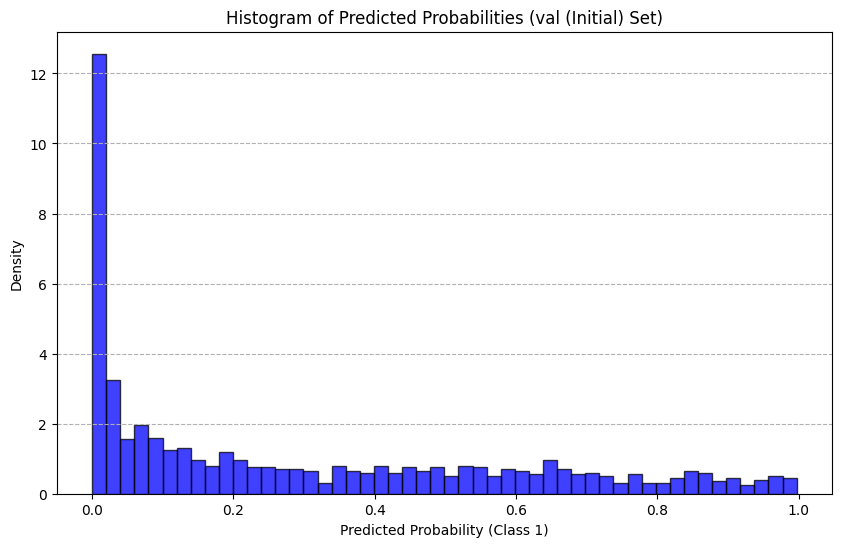


Area Under ROC Curve (AUC): 0.8159

Calculating metrics across different thresholds...
Best Threshold (Maximizing F1): 0.6234
Best F1 Score at this threshold: 0.4969


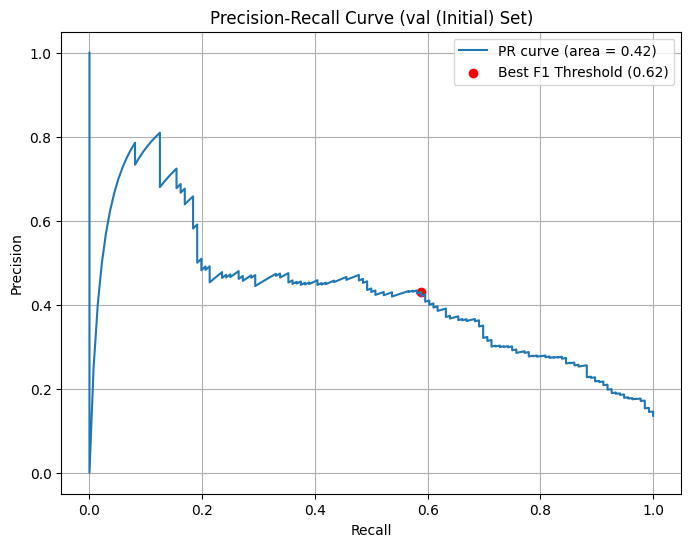


Metrics using threshold = 0.6234:
              precision    recall  f1-score   support

         0.0       0.93      0.88      0.90       866
         1.0       0.43      0.59      0.50       136

    accuracy                           0.84      1002
   macro avg       0.68      0.73      0.70      1002
weighted avg       0.86      0.84      0.85      1002


Metrics using threshold = 0.5000:
              precision    recall  f1-score   support

         0.0       0.94      0.80      0.87       866
         1.0       0.35      0.69      0.47       136

    accuracy                           0.79      1002
   macro avg       0.65      0.75      0.67      1002
weighted avg       0.86      0.79      0.81      1002

--- Analysis Complete ---


In [ ]:
# ---------------------------------------------------------------------------
# How to Use
# ---------------------------------------------------------------------------

# --- Using the Standalone Function ---
# Assume 'mymodel' is your trained model after calling train_transfer_model
# or loaded from saved weights.
# Assume 'val_dataset' is your validation tf.data.Dataset

# analyze_model_outputs(mymodel, val_dataset, dataset_name="Validation")

# If you saved weights after initial training and want to analyze that state:
initial_weights_path = os.path.join("/home/arash/tooth_classification_project/logs/tensorboard", "resnet50/20250425-095439/initial_weights_1_.h5") # Get the correct path
# model_arch = 'ConvNeXtTiny' # Or whichever architecture was used
# input_s = (224, 224, 3) # Use your actual input shape
model_for_initial_analysis = create_model(my_config, 'transfer', trainable_base = False) # Build with same structure
model_for_initial_analysis.load_weights(initial_weights_path)
model_for_initial_analysis = compile_model(model_for_initial_analysis, my_config, my_config.INITIAL_LR)
print("\nAnalyzing model state AFTER INITIAL training:")
analyze_model_outputs(model_for_initial_analysis, val_ds, dataset_name=f"{dataset_name} (Initial)")

In [18]:
model_for_initial_analysis.summary()

Model: "resnet50_model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 preprocessing_layer (Lambd  (None, 256, 256, 3)          0         ['input_4[0][0]']             
 a)                                                                                               
                                                                                                  
 resnet50 (Functional)       (None, 8, 8, 2048)           2358771   ['preprocessing_layer[0][0]'] 
                                                          2                                       
                                                                                     

In [19]:
import tensorflow as tf
import numpy as np

# Define (or load) your model as described in the previous example.

# Calculate the total number of trainable parameters.
trainable_param_count = np.sum([tf.keras.backend.count_params(w) for w in model_for_initial_analysis.trainable_weights])
print("Total trainable parameters:", trainable_param_count)

Total trainable parameters: 1090817


In [20]:
# dataset= val_ds
# batch_number= 120
# """
# Prints the records for the desired batch number (1-indexed) from the dataset.

# Args:
#     dataset (tf.data.Dataset): The tf.data.Dataset instance.
#     batch_number (int): The desired batch number (1-indexed).
# """
# # Convert batch_number to zero-indexed for skip: the first batch is batch 0.
# target_idx = batch_number - 1

# # Use skip and take to get the desired batch.
# desired_batch = dataset.skip(target_idx).take(1)

# # Flag to check if batch exists.
# batch_found = False

# for batch in desired_batch:
#     batch_found = True
#     # Assuming each batch is a tuple: (images, labels)
#     images, labels = batch
#     print(f"Batch {batch_number}:")
#     print("Images shape:", images.shape)
#     # For example, print out the labels; you can print images in more detail if needed.
#     print("Labels:", labels.numpy())

# if not batch_found:
#     print(f"Batch {batch_number} not found in the dataset.")

In [21]:
# """
# Plots each image in the specified batch (1-indexed) with its label.

# Args:
#     dataset (tf.data.Dataset): The dataset output from build_tf_dataset_from_preprocessed().
#     batch_number (int): The desired batch number to display (1-indexed).
# """
# # Adjust for 0-index (first batch is batch 0)
# target_idx = batch_number - 1

# # Get the desired batch using skip() and take().
# desired_batch = dataset.skip(target_idx).take(1)

# # Loop through the batch (should have only one batch)
# for batch in desired_batch:
#     # The dataset returns a tuple (images, labels)
#     images, labels = batch
    
#     # Determine number of images in the batch
#     num_images = images.shape[0]
    
#     # Create a figure with one subplot per image
#     plt.figure(figsize=(num_images * 3, 3))
#     for i in range(num_images):
#         plt.subplot(1, num_images, i + 1)
#         # Convert the image tensor to a NumPy array.
#         # If the image values are floats in [0, 255] then convert to uint8, otherwise adjust as needed.
#         image_np = images[i].numpy()
#         # Optionally, if you want to ensure 0-255 format, you might do:
#         if np.issubdtype(image_np.dtype, np.floating):
#             image_np = np.clip(image_np, 0, 255).astype(np.uint8)
#         plt.imshow(image_np)
#         # Print the label as the title
#         plt.title(f"Label: {labels[i].numpy()}")
#         plt.axis("off")
#     plt.show()

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def plot_probabilities_per_record(trained_model: tf.keras.Model,
                                   val_dataset: tf.data.Dataset,
                                   config: Config,
                                   dataset_name: str = "Validation",
                                   ):
    """
    Gets the final probability predictions (post-sigmoid, pre-threshold) 
    from the model for each record in the validation set and plots them,
    colored by true class, to help assess the classification threshold.

    Args:
        trained_model: The trained Keras model ending with a sigmoid activation 
                       (like the one from your build_pretrained_model function).
        val_dataset: The tf.data.Dataset to evaluate on.
        dataset_name: Name for plot titles (e.g., "Validation", "Test").
    """
    print(f"\n--- Plotting Probabilities (Post-Sigmoid) for {dataset_name} Set ---")

    # --- Get Probability Predictions ---
    # Use the original model directly. Its output IS the probability 
    # because the last layer has sigmoid activation.
    print(f"Getting probability predictions for {dataset_name} set...")
    try:
        # This gets the output AFTER the sigmoid activation
        probabilities = trained_model.predict(val_dataset) 
        # Ensure predictions are flattened to a 1D array
        probabilities = probabilities.flatten() 
    except Exception as e:
        print(f"Error during probability prediction: {e}")
        return
        
    # --- Get True Labels ---
    print("Gathering true labels...")
    try:
        true_labels = []
        # Ensure iteration covers the whole dataset if not cached/repeated
        for _, y_batch in val_dataset: 
            true_labels.append(y_batch.numpy())
        # Ensure labels are flattened to a 1D array
        true_labels = np.concatenate(true_labels, axis=0).flatten()
    except Exception as e:
        print(f"Error extracting true labels: {e}")
        return

    # --- Verify Counts ---
    if len(probabilities) != len(true_labels):
        print(f"\nError: Mismatch between probability count ({len(probabilities)}) "
              f"and label count ({len(true_labels)}).")
        print("Check model's final layer output shape (should be 1) and dataset structure.")
        print("Cannot proceed with plotting.")
        return
        
    print(f"Successfully gathered {len(true_labels)} labels and {len(probabilities)} probabilities.")

    # --- Plot Probabilities per Record ---
    print("Plotting probabilities...")
    plt.figure(figsize=(15, 8)) # Slightly larger figure
    
    indices = np.arange(len(true_labels))
    
    # Separate data based on true label for color-coding
    indices_class0 = indices[true_labels == 0]
    probabilities_class0 = probabilities[true_labels == 0]
    
    indices_class1 = indices[true_labels == 1]
    probabilities_class1 = probabilities[true_labels == 1]

    # Create the scatter plot
    plt.scatter(indices_class0, probabilities_class0, alpha=0.6, s=10, 
                label=f'True Class 0 ({len(indices_class0)} samples)', c='royalblue')
    plt.scatter(indices_class1, probabilities_class1, alpha=0.6, s=10, 
                label=f'True Class 1 ({len(indices_class1)} samples)', c='darkorange')

    # Add a horizontal line at probability=0.5 (the default threshold)
    plt.axhline(config.METRIC_THRESHOLDS[0], color='red', linestyle='--', linewidth=1.5, label=f'Threshold = {config.METRIC_THRESHOLDS[0]}')

    plt.title(f'Predicted Probabilities (Post-Sigmoid) per Record ({dataset_name} Set)')
    plt.xlabel('Validation Record Index')
    plt.ylabel('Predicted Probability (Class 1)')
    plt.ylim(-0.05, 1.05) # Set Y axis limits slightly beyond 0 and 1 for clarity
    plt.legend(loc='best') # Automatically find best location for legend
    plt.grid(True, axis='y', linestyle=':')
    plt.tight_layout() # Adjust layout
    plt.show()
    
    print("--- Probability Plotting Complete ---")




--- Plotting Probabilities (Post-Sigmoid) for val Set ---
Getting probability predictions for val set...


2025-04-23 10:31:45.254075: W tensorflow/core/grappler/optimizers/loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: cond/then/_0/cond/cond_tfg_inlined_cond_0/else/_39/cond/cond/cond_tfg_inlined_cond/cond_tfg_inlined_cond_0_1/branch_executed/_77
2025-04-23 10:31:45.363452: W tensorflow/core/grappler/optimizers/loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: cond/then/_0/cond/cond_tfg_inlined_cond_0/else/_39/cond/cond/cond_tfg_inlined_cond/cond_tfg_inlined_cond_0_1/branch_executed/_77


32/32 [==============================] - 3s 91ms/step
Gathering true labels...


2025-04-23 10:31:48.360177: W tensorflow/core/grappler/optimizers/loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: cond/then/_0/cond/cond_tfg_inlined_cond_0/else/_39/cond/cond/cond_tfg_inlined_cond/cond_tfg_inlined_cond_0_1/branch_executed/_77


Successfully gathered 1002 labels and 1002 probabilities.
Plotting probabilities...


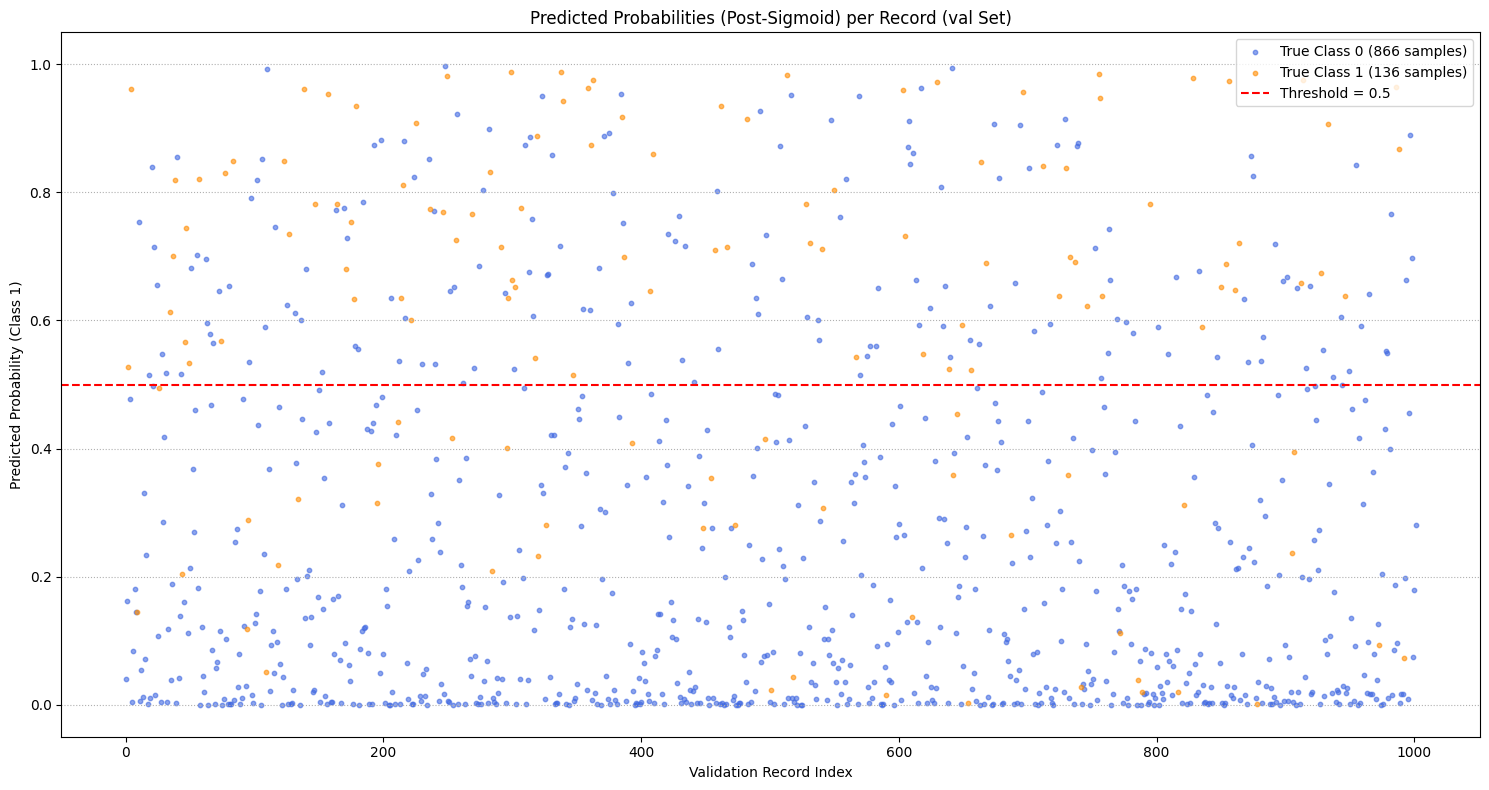

--- Probability Plotting Complete ---


In [23]:
# --- How to Use ---
# Assume 'mymodel' is your trained model returned from build_pretrained_model 
# (and potentially trained further by train_transfer_model)
# Assume 'val_dataset' is your validation tf.data.Dataset

plot_probabilities_per_record(model_for_initial_analysis, val_ds, dataset_name=dataset_name, config=my_config)


In [24]:
model_for_initial_analysis.summary()

Model: "resnet50_model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 preprocessing_layer (Lambd  (None, 256, 256, 3)          0         ['input_4[0][0]']             
 a)                                                                                               
                                                                                                  
 resnet50 (Functional)       (None, 8, 8, 2048)           2358771   ['preprocessing_layer[0][0]'] 
                                                          2                                       
                                                                                     

In [25]:
model = model_for_initial_analysis
for i, layer in enumerate(model.layers):
    if i < 4:
        layer.trainable = False
    else:
        print(f"layer {i} set to trainable")
        layer.trainable = True
print(f"Layer {15} and higher set to trainable in fine tuning step.")

model.trainable_weights

layer 4 set to trainable
layer 5 set to trainable
layer 6 set to trainable
layer 7 set to trainable
layer 8 set to trainable
layer 9 set to trainable
layer 10 set to trainable
layer 11 set to trainable
layer 12 set to trainable
layer 13 set to trainable
layer 14 set to trainable
Layer 15 and higher set to trainable in fine tuning step.


[<tf.Variable 'head_bn_1/gamma:0' shape=(4096,) dtype=float32, numpy=
 array([1.0102956 , 0.9952308 , 0.9975633 , ..., 1.009517  , 0.99197245,
        1.0032344 ], dtype=float32)>,
 <tf.Variable 'head_bn_1/beta:0' shape=(4096,) dtype=float32, numpy=
 array([-0.00203082,  0.00187624,  0.00239149, ..., -0.00092467,
         0.0003906 , -0.00296941], dtype=float32)>,
 <tf.Variable 'head_dense_1/kernel:0' shape=(4096, 256) dtype=float32, numpy=
 array([[-9.59107466e-03,  8.54178611e-03, -2.15387084e-02, ...,
         -3.16486973e-03, -4.17800038e-06,  5.00295451e-03],
        [-6.27494301e-04, -6.71568839e-03, -9.00223211e-04, ...,
          1.08720027e-02, -4.60445462e-03, -4.79366444e-03],
        [ 8.74019170e-04, -8.17973725e-03, -2.90771015e-03, ...,
          2.90465169e-03, -1.87067743e-02,  2.95046740e-03],
        ...,
        [-7.52436835e-03,  3.34603386e-03,  9.74242575e-03, ...,
         -3.75104748e-04,  2.24443637e-02,  5.07016759e-03],
        [ 1.51849696e-02,  8.53667315e

In [26]:



# --- Using the Custom Callback ---
# Modify your `train_transfer_model` function:

def train_transfer_model(mymodel, train_dataset, val_dataset, config: Config, save_models = True,
                         initial_weights_name="initial_weights",
                         fine_tuned_weights_name="fine_tuned_weights",
                         num = 1):

    # ... (previous setup code like log_dir creation) ...
    
    # Instantiate the custom callback
    # Decide how often you want the analysis (e.g., run_freq=3 means every 3 epochs)
    # Make sure log_dir is defined before this line
    output_analysis_callback = OutputAnalysisCallback(
        validation_data=val_dataset, 
        log_dir=os.path.join(log_dir, "output_analysis"), # Save plots in a subfolder
        run_freq=3 # Example: run every 3 epochs
    )

    # Add the callback to your lists
    initial_callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True), # Consider monitoring val_auc mode='max'
        ReduceLROnPlateau( monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1), # Consider monitoring val_auc mode='max'
        tensorboard_callback,
        output_analysis_callback # Add it here
    ]
    
    # ... (compile model for initial training) ...
    
    print("**************** Starting initial training **************** ")
    initial_history = mymodel.fit(
        # ...,
        callbacks=initial_callbacks,
        # ...
    )
    
    # ... (save initial weights / history logging) ...

    if config.NUM_FINE_TUNE_EPOCHS > 0:
        # ... (fine-tuning setup: unfreeze layers, etc.) ...
        
        # Define fine-tuning callbacks, INCLUDING the analysis callback again
        fine_tune_callbacks = [
            EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True), # Consider val_auc
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1), # Consider val_auc
            tensorboard_callback,
            output_analysis_callback # Add it here too
        ]
        
        # ... (compile model for fine-tuning) ...
        
        fine_tune_history = mymodel.fit(
            # ...,
            callbacks=fine_tune_callbacks,
            # ...
        )
        
        # ... (save fine-tuned weights / history logging) ...
    
    # ... (return statement) ...